# OASIS-1 Multitask MRI Demo

This notebook evaluates the small public-data reproduction demo:

- Input: single T1 MRI per subject
- Segmentation target: FSL FAST tissue labels
- Classification target: `CDR == 0` vs `CDR > 0`
- Cognitive target: MMSE

This is a pipeline proof on a 16-subject OASIS-1 subset, not a scientific performance claim.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, mean_absolute_error, mean_squared_error
from torch.utils.data import DataLoader

PROJECT = Path.cwd()
if not (PROJECT / "src").exists():
    PROJECT = PROJECT.parent
os.chdir(PROJECT)
sys.path.insert(0, str(PROJECT))

from src.data import MriMultitaskDataset
from src.metrics import dice_score
from src.train_multitask import LitMultitask, load_config

CONFIG_PATH = PROJECT / "configs" / "oasis1_demo_multitask.yaml"
CHECKPOINT_PATH = PROJECT / "models" / "oasis1_demo_multitask.ckpt"

config = load_config(CONFIG_PATH)
config, CHECKPOINT_PATH.exists()

({'seed': 42,
  'task': 'oasis1_demo_multitask',
  'manifest': 'data/manifests/oasis1_demo_manifest.csv',
  'segmentation_root': 'data/processed/oasis/fast_demo',
  'output_dir': 'outputs/oasis1_demo_multitask',
  'pretrained_checkpoint': 'models/hcp_demo_smoke.ckpt',
  'checkpoint_path': 'models/oasis1_demo_multitask.ckpt',
  'target_shape': [64, 64, 64],
  'batch_size': 1,
  'num_workers': 0,
  'max_epochs': 2,
  'learning_rate': 0.0001,
  'cognitive_target': 'mmse',
  'label_column': 'label',
  'loss_weights': {'segmentation': 0.5,
   'classification': 1.0,
   'cognition': 0.05}},
 True)

## Dataset Manifest

In [2]:
manifest = pd.read_csv(config["manifest"])
display(manifest[["subject_id", "age", "sex", "mmse", "cdr", "label"]])

summary = pd.DataFrame({
    "n_subjects": [len(manifest)],
    "controls_cdr0": [(manifest["label"] == 0).sum()],
    "impaired_cdr_gt0": [(manifest["label"] == 1).sum()],
    "mmse_min": [manifest["mmse"].min()],
    "mmse_max": [manifest["mmse"].max()],
})
display(summary)

,subject_id,age,sex,mmse,cdr,label
0,OAS1_0001_MR1,74,F,29.0,0.0,0
1,OAS1_0002_MR1,55,F,29.0,0.0,0
2,OAS1_0003_MR1,73,F,27.0,0.5,1
3,OAS1_0010_MR1,74,M,30.0,0.0,0
4,OAS1_0011_MR1,52,F,30.0,0.0,0
5,OAS1_0013_MR1,81,F,30.0,0.0,0
6,OAS1_0018_MR1,39,M,28.0,0.0,0
7,OAS1_0019_MR1,89,F,30.0,0.0,0
8,OAS1_0021_MR1,80,F,23.0,0.5,1
9,OAS1_0022_MR1,69,F,23.0,0.5,1


,n_subjects,controls_cdr0,impaired_cdr_gt0,mmse_min,mmse_max
0,16,8,8,23.0,30.0


## Load Model And Predict

In [3]:
dataset = MriMultitaskDataset(
    manifest_path=config["manifest"],
    segmentation_root=config["segmentation_root"],
    target_shape=tuple(config["target_shape"]),
    cognitive_target=config["cognitive_target"],
    label_column=config["label_column"],
    require_segmentation=True,
)
loader = DataLoader(dataset, batch_size=1, shuffle=False)

model = LitMultitask.load_from_checkpoint(CHECKPOINT_PATH, config=config, map_location="cpu")
model.eval()

rows = []
dice_values = []
with torch.no_grad():
    for batch in loader:
        outputs = model(batch["image"])
        prob = torch.sigmoid(outputs["diagnosis_logit"]).view(-1).item()
        pred_label = int(prob >= 0.5)
        pred_mmse = outputs["cognition"].view(-1).item()
        dice = dice_score(outputs["segmentation"], batch["segmentation"]).item()
        dice_values.append(dice)
        rows.append({
            "subject_id": batch["subject_id"][0],
            "true_label": int(batch["label"].item()),
            "pred_label": pred_label,
            "dementia_probability": prob,
            "true_mmse": float(batch["cognition"].item()),
            "pred_mmse": pred_mmse,
            "seg_dice": dice,
        })

predictions = pd.DataFrame(rows)
display(predictions)

,subject_id,true_label,pred_label,dementia_probability,true_mmse,pred_mmse,seg_dice
0,OAS1_0001_MR1,0,1,0.500866,29.0,0.082564,0.640804
1,OAS1_0002_MR1,0,1,0.501048,29.0,0.082590,0.670328
2,OAS1_0003_MR1,1,1,0.500932,27.0,0.082375,0.634441
3,OAS1_0010_MR1,0,1,0.500727,30.0,0.082950,0.631476
4,OAS1_0011_MR1,0,1,0.501069,30.0,0.082203,0.674809
5,OAS1_0013_MR1,0,1,0.500708,30.0,0.082370,0.627407
6,OAS1_0018_MR1,0,1,0.501175,28.0,0.082505,0.686675
7,OAS1_0019_MR1,0,1,0.501209,30.0,0.083088,0.630636
8,OAS1_0021_MR1,1,1,0.500676,23.0,0.082402,0.626149
9,OAS1_0022_MR1,1,1,0.500973,23.0,0.082168,0.663297


## Metrics

,accuracy,balanced_accuracy,mmse_mae,mmse_rmse,mean_seg_dice
0,0.5,0.5,27.667496,27.752068,0.644587


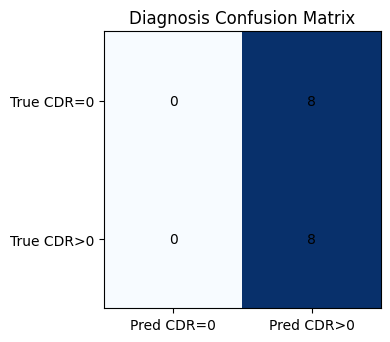

In [4]:
y_true = predictions["true_label"]
y_pred = predictions["pred_label"]
mmse_true = predictions["true_mmse"]
mmse_pred = predictions["pred_mmse"]

metrics = pd.DataFrame({
    "accuracy": [accuracy_score(y_true, y_pred)],
    "balanced_accuracy": [balanced_accuracy_score(y_true, y_pred)],
    "mmse_mae": [mean_absolute_error(mmse_true, mmse_pred)],
    "mmse_rmse": [mean_squared_error(mmse_true, mmse_pred) ** 0.5],
    "mean_seg_dice": [float(np.mean(dice_values))],
})
display(metrics)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], labels=["Pred CDR=0", "Pred CDR>0"])
ax.set_yticks([0, 1], labels=["True CDR=0", "True CDR>0"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
ax.set_title("Diagnosis Confusion Matrix")
plt.tight_layout()
plt.show()

## Example MRI And FAST Segmentation Slices

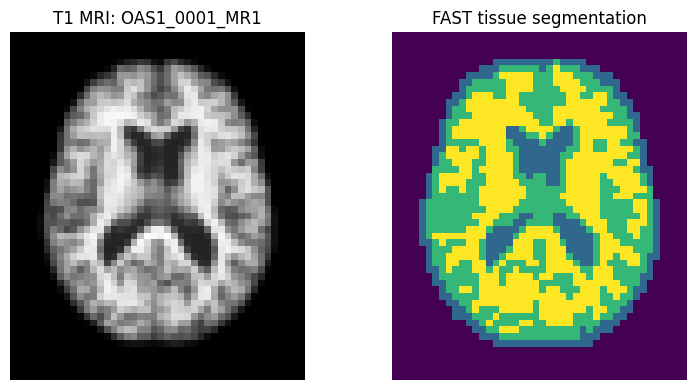

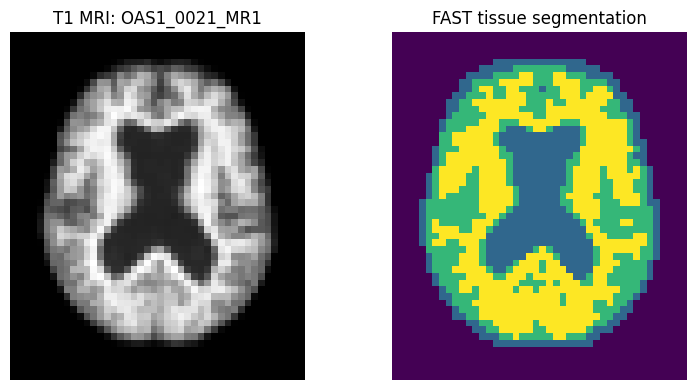

In [5]:
def show_subject(row_index: int = 0) -> None:
    row = manifest.iloc[row_index]
    image = nib.load(row["mri_path"]).get_fdata()
    seg = nib.load(row["segmentation_path"]).get_fdata()
    z = image.shape[2] // 2

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(np.rot90(image[:, :, z]), cmap="gray")
    axes[0].set_title(f"T1 MRI: {row['subject_id']}")
    axes[0].axis("off")

    axes[1].imshow(np.rot90(seg[:, :, z]), cmap="viridis", vmin=0, vmax=3)
    axes[1].set_title("FAST tissue segmentation")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

show_subject(0)
show_subject(8)

## Interpretation

This notebook demonstrates that the reproduction scaffold can run end-to-end on public substitute data. The current 16-subject OASIS-1 run is intentionally tiny and downsampled, so its metrics are only a technical sanity check. The next scientific step is to scale to more OASIS subjects, use a fixed train/validation/test split, and compare against baselines.